# Ungridded and non-raster scans

> Sample: graphene substrate ducky
>
> Sampling conditions: 4 Ang step-sizes, decimated and non-raster
>
> Imaging conditions: 20 mrad, 500 A defocus

Direct ptychography kernels are multipliers on the scan-space Fourier transform, so `DirectPtychography` needs the probe positions on a regular grid.
This notebook covers what to do when they are not, using `DirectPtychographyMontage`, which accumulates each virtual bright-field image onto a shared real-space canvas and never transforms over the scan.

Both classes accept ungridded input through `from_dataset3d`, and theytake different routes to it.
`DirectPtychography.from_dataset3d` resamples the positions onto a grid first, then runs the ordinary Fourier reconstruction. `DirectPtychographyMontage.from_dataset3d` uses the positions as measured.
We build up to that with three decimations of one raster dataset, then a genuinely non-raster scan.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import quantem as em

from quantem.core.datastructures import Dataset3d

/Users/gvarnavides/Documents/git-repos/quantem-upstream/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = em.core.io.load("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dataset

Dataset(shape=(37, 37, 200, 200), dtype=float32, name='ducky_251105_clean')
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'

In [3]:
energy = 80e3
semiangle_cutoff = 20
defocus = -500
rotation_angle_deg = 0

kwargs = dict(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    rotation_angle=rotation_angle_deg,
    aberration_coefs={"C10": defocus},
)

step = float(dataset.sampling[0])
num_rows, num_cols = dataset.shape[:2]
field_of_view = (num_rows * step, num_cols * step)

# the scan step is coarse enough that a reconstruction sampled on it aliases, so every
# comparison below is made on a canvas refined by this factor
upsampling = 2

fine = step / upsampling

print(f"{num_rows} x {num_cols} scan positions, {step} A step, {field_of_view[0]:.0f} A field")

37 x 37 scan positions, 4.0 A step, 148 A field


## 1. The two classes on a raster scan

Before decimating anything, it is worth seeing how the two classes compare when both are
given the same complete raster scan.

In [4]:
fourier = em.diffractive_imaging.DirectPtychography.from_dataset4d(dataset, verbose=False, **kwargs)
montage = em.diffractive_imaging.DirectPtychographyMontage.from_dataset4d(dataset, boundary="wrap", verbose=False, **kwargs)


def correlation(a, b):
    a, b = np.asarray(a, float).ravel(), np.asarray(b, float).ravel()
    a, b = a - a.mean(), b - b.mean()
    return float((a * b).sum() / np.sqrt((a * a).sum() * (b * b).sum()))


def score(reconstruction, reference, fine_sampling):
    # Constructors anchor the canvas differently. `from_dataset4d` starts at scan pixel
    # (0, 0), while `from_dataset3d` anchors at the bounding box of the positions it was
    # given, and a padded canvas can start before the first position. `obj_origin` records
    # that corner, so we use it to line the two up rather than assuming they agree.
    obj = np.asarray(reconstruction.obj)
    offset = np.round(np.asarray(reconstruction.obj_origin) / fine_sampling).astype(int)

    rows = slice(max(0, offset[0]), min(reference.shape[0], offset[0] + obj.shape[0]))
    cols = slice(max(0, offset[1]), min(reference.shape[1], offset[1] + obj.shape[1]))
    crop = obj[rows.start - offset[0] : rows.stop - offset[0],
               cols.start - offset[1] : cols.stop - offset[1]]
    return correlation(crop, reference[rows, cols])

For the `ssb`, `obf`, `mf` and `icom` kernels the two agree to floating-point precision.
Both build the same Fourier kernel, and the montage evaluates the convolution by FFT on the canvas rather than as a multiplier in scan space.

In [5]:
fourier.reconstruct(deconvolution_kernel="ssb", upsampling_factor=upsampling, verbose=False)
montage.reconstruct(deconvolution_kernel="ssb", upsampling_factor=upsampling, verbose=False)

ssb_fourier = np.asarray(fourier.obj)
ssb_montage = np.asarray(montage.obj)
print(f"ssb correlation: {correlation(ssb_fourier, ssb_montage):.6f}")
print(f"max abs difference / rms: {np.abs(ssb_fourier - ssb_montage).max() / ssb_fourier.std():.2e}")

ssb correlation: 1.000000
max abs difference / rms: 1.41e-06


The `prlx` kernel is the exception.
It is a pure translation of each bright-field image, and the montage performs it by depositing onto canvas pixels rather than by applying an exact Fourier shift.
That deposition is the one approximation the montage makes.
Its error is a fixed fraction of a canvas pixel, so refining the canvas with `upsampling_factor` reduces it, though not smoothly, since which shifts happen to land near a pixel centre changes as well.
`interpolation="bilinear"` spreads each shift over the neighbouring pixels instead of snapping to one, which helps when the positions are not on a lattice.

In [6]:
for upsampling_factor in (1, 2, 4):
    fourier.reconstruct(
        deconvolution_kernel="prlx", upsampling_factor=upsampling_factor, verbose=False
    )
    montage.reconstruct(
        deconvolution_kernel="prlx", upsampling_factor=upsampling_factor, verbose=False
    )
    agreement = correlation(fourier.obj, montage.obj)
    print(f"upsampling_factor={upsampling_factor}: prlx correlation {agreement:.4f}")

upsampling_factor=1: prlx correlation 0.9520
upsampling_factor=2: prlx correlation 0.9893
upsampling_factor=4: prlx correlation 0.9850


reference: (74, 74)


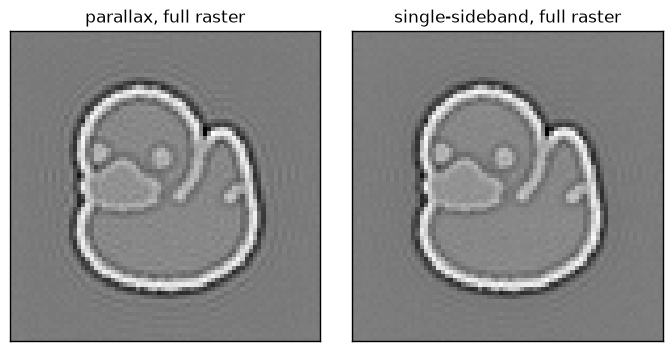

In [7]:
fourier.reconstruct(deconvolution_kernel="prlx", upsampling_factor=upsampling, verbose=False)
raster_reference = np.asarray(fourier.obj)
print(f"reference: {raster_reference.shape}")

em.visualization.show_2d(
    [raster_reference, ssb_montage],
    title=["parallax, full raster", "single-sideband, full raster"],
    axsize=(3.5, 3.5),
    norm="minmax",
);

## 2. Checkerboard decimation

Now we keep every other position, which leaves 685 of the 1369. To pass these to
`from_dataset3d` we need a `Dataset3d` of diffraction patterns and an `(N, 2)` array of
positions in Angstrom, ordered `(row, col)` to match the diffraction axes.

In [8]:
rows, cols = np.mgrid[:num_rows, :num_cols]


def decimate(mask):
    """Diffraction patterns and probe positions for the kept subset of a raster scan."""
    positions = np.stack([rows[mask], cols[mask]], axis=-1).astype(float) * step
    patterns = Dataset3d.from_array(
        np.ascontiguousarray(dataset.array[mask]),
        sampling=(1.0, *dataset.sampling[2:]),
        units=("index", *dataset.units[2:]),
    )
    return patterns, positions


checkerboard = (rows + cols) % 2 == 0
checker_patterns, checker_positions = decimate(checkerboard)
print(f"kept {checkerboard.sum()} of {checkerboard.size} positions")

kept 685 of 1369 positions


`scan_sampling` sets the canvas pixel size, and `"auto"` infers it from the median nearest-neighbour spacing of the positions.
That is worth looking at here, because the answer is not the 4 A step we started from.

In [9]:
inferred = em.diffractive_imaging.DirectPtychographyMontage.from_dataset3d(
    checker_patterns, checker_positions, verbose=False, **kwargs
)
print(f"inferred scan_sampling: {np.round(inferred.scan_sampling, 3)} A")
print(f"4 * sqrt(2) = {4 * np.sqrt(2):.3f}")

inferred scan_sampling: [5.657 5.657] A
4 * sqrt(2) = 5.657


/var/folders/4k/wtzmrt4x0sq19vz44dn3cwzwkblbyl/T/ipykernel_90253/419555587.py:1: UserWarning: Inferred scan_sampling=(5.656854249492381, 5.656854249492381) Angstrom from the median nearest-neighbour position spacing.
  inferred = em.diffractive_imaging.DirectPtychographyMontage.from_dataset3d(


A checkerboard subset of a square lattice is itself a square lattice, rotated by 45 degrees and with a nearest-neighbour spacing of `4 * sqrt(2)`.
The inference is measuring the right thing, but for comparing against the full raster we want the original 4 A canvas, so we pass `scan_sampling` explicitly.

The two classes reach the refined canvas by different routes, and it matters which one you use.
The montage never grids the positions, so `upsampling_factor` at reconstruct time is equivalent to having built it with a proportionally finer `scan_sampling`.
The regridded route has already binned the measurements onto a lattice by the time `reconstruct` is called, so upsampling there would interpolate what the binning discarded.
It gets the finer canvas from `scan_sampling` at construction instead, which is where the positions are still known.

The montage also takes `obj_origin` and `obj_fov`, which pin the canvas to a fixed window in the coordinates the positions were given in.
Without them the canvas follows the bounding box of whatever positions it was handed, so two reconstructions of the same region can end up a few pixels apart.

In [10]:
checker_montage = em.diffractive_imaging.DirectPtychographyMontage.from_dataset3d(
    checker_patterns, checker_positions, scan_sampling=(step, step), verbose=False, **kwargs
)
checker_montage.reconstruct(
    deconvolution_kernel="prlx",
    upsampling_factor=upsampling,
    obj_origin=(0.0, 0.0),
    obj_fov=field_of_view,
    verbose=False,
)

checker_regrid = em.diffractive_imaging.DirectPtychography.from_dataset3d(
    checker_patterns,
    checker_positions,
    scan_sampling=(step / upsampling, step / upsampling),
    scan_gpts=(num_rows * upsampling, num_cols * upsampling),
    verbose=False,
    **kwargs,
)
checker_regrid.reconstruct(deconvolution_kernel="prlx", verbose=False)

print(f"montage:   {score(checker_montage, raster_reference, fine):+.3f}")
print(f"regridded: {score(checker_regrid, raster_reference, fine):+.3f}")

montage:   +0.986
regridded: +0.997


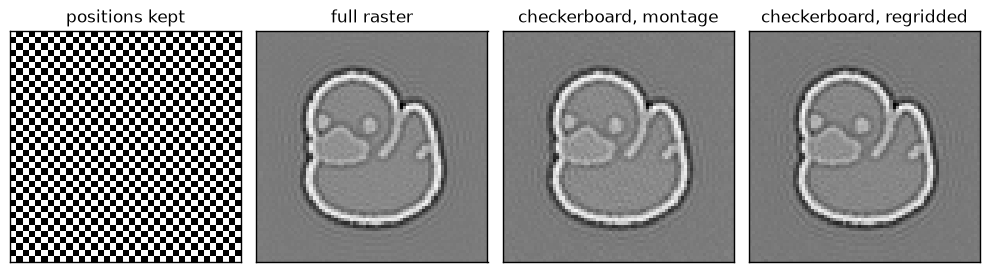

In [15]:
em.visualization.show_2d(
    [
        checkerboard.astype(float),
        raster_reference,
        np.asarray(checker_montage.obj),
        np.asarray(checker_regrid.obj),
    ],
    title=["positions kept", "full raster", "checkerboard, montage", "checkerboard, regridded"],
    axsize=(2.5, 2.8),
    norm="minmax",
);

Both recover ducky, and the regridded route scores slightly higher.
A checkerboard leaves half the grid empty but spreads the gaps evenly, and scattered empty pixels behave much like noise once the deconvolution spreads them out.
This is close to the best case for regridding, so it is not an argument for either class on its own.

## 3. Random subsampling

A more useful decimation is a random subset of the positions.
Acquiring a fraction of a scan and reconstructing from it is the compressive sensing approach to dose, and it is a realistic thing to want to do, where a checkerboard is not.

We sweep the kept fraction down until the reconstruction stops being usable.

In [12]:
rng = np.random.default_rng(2025)
fractions = (0.5, 0.3, 0.2, 0.1, 0.05, 0.02)

subsampled = {}
print(f"{'keep':>6} {'N':>5} {'montage':>9} {'regridded':>10}")

for fraction in fractions:
    mask = rng.random((num_rows, num_cols)) < fraction
    patterns, positions = decimate(mask)

    sub_montage = em.diffractive_imaging.DirectPtychographyMontage.from_dataset3d(
        patterns, positions, scan_sampling=(step, step), verbose=False, **kwargs
    )
    sub_montage.reconstruct(
        deconvolution_kernel="prlx",
        upsampling_factor=upsampling,
        obj_origin=(0.0, 0.0),
        obj_fov=field_of_view,
        verbose=False,
    )

    sub_regrid = em.diffractive_imaging.DirectPtychography.from_dataset3d(
        patterns,
        positions,
        scan_sampling=(fine, fine),
        scan_gpts=(num_rows * upsampling, num_cols * upsampling),
        verbose=False,
        **kwargs,
    )
    sub_regrid.reconstruct(deconvolution_kernel="prlx", verbose=False)

    subsampled[fraction] = (mask, np.asarray(sub_montage.obj))
    print(
        f"{fraction:6.0%} {mask.sum():5d} "
        f"{score(sub_montage, raster_reference, fine):+9.3f} "
        f"{score(sub_regrid, raster_reference, fine):+10.3f}"
    )

  keep     N   montage  regridded
   50%   688    +0.983     +0.981
   30%   364    +0.968     +0.917
   20%   254    +0.939     +0.877
   10%   117    +0.843     +0.814
    5%    65    +0.680     +0.714
    2%    34    +0.564     +0.581


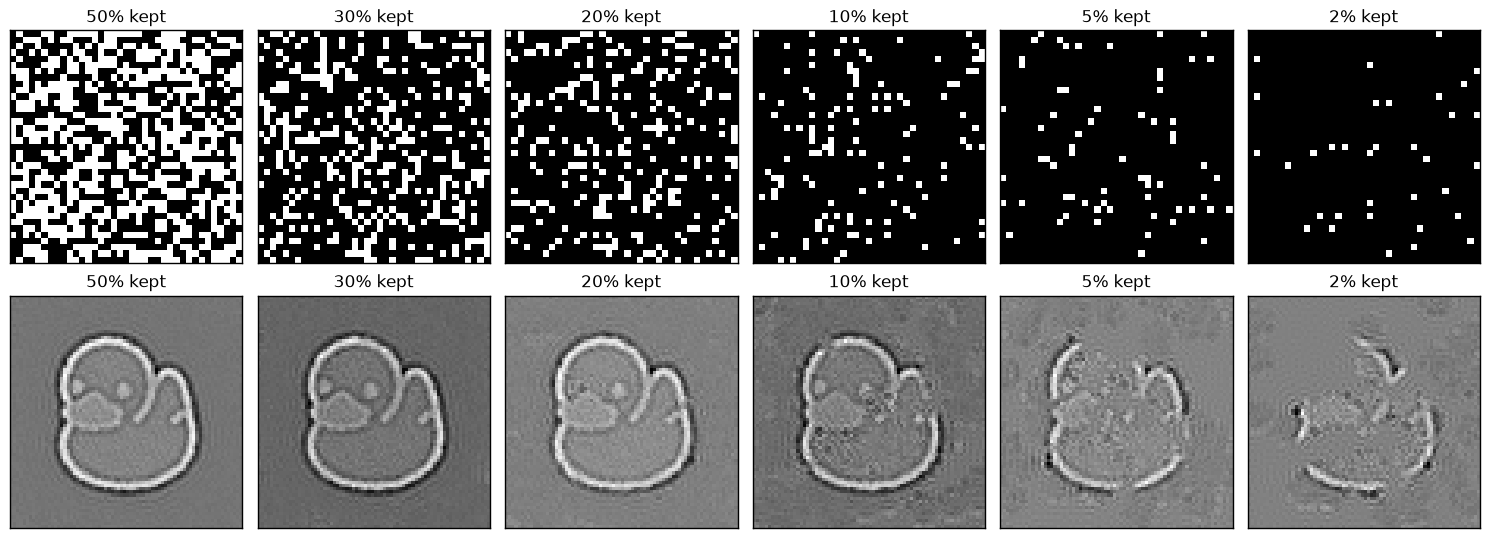

In [14]:
em.visualization.show_2d(
    [
        [
            subsampled[f][0].astype(float) for f in fractions
        ],
        [
            subsampled[f][1] for f in fractions
            ],
    ],
    title=[f"{f:.0%} kept" for f in fractions],
    axsize=(2.5, 2.8),
    norm="minmax",
);

Both classes degrade gradually rather than failing at some threshold.
The duck stays recognisable down to about 10% of the positions, which is around 130 of the original 1369,
and by 2% neither reconstruction is usable.
Through the middle of the range the montage holds a small lead, which is what not having to bin the positions onto a grid buys.

## 4. A non-raster scan

Everything above is a subset of a grid, so the positions still land on lattice points.
This last dataset is simulated directly on a hexagonal lattice, which has no grid underneath it.
It is produced by `simulation_notebooks/ducky-dataset-nonraster.ipynb` on the same object atthe same dose, with a 4.5 A nearest-neighbour spacing.

In [16]:
hex_patterns = em.core.io.load("../../data/ducky_20mrad_500A-df_4.5A-hex_5e+04-dose.zip")
hex_positions = np.asarray(
    em.core.io.load("../../data/ducky_20mrad_500A-df_4.5A-hex_5e+04-dose_positions.zip").array
)

print(hex_patterns.shape, hex_positions.shape)

(1068, 200, 200) (1068, 2)


The two simulations do not share an origin.
The raster dataset was scanned over 8 to 152 A, and a saved `Dataset4dstem` carries its sampling but not where the scan began, so the raster reconstruction treats its first probe position as the origin.
The hexagonal positions are in absolute coordinates, so we subtract the raster scan's starting corner to bring the two into
the same frame.

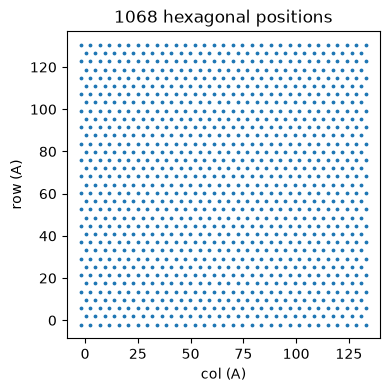

In [17]:
RASTER_SCAN_START = 8.0  # abtem.GridScan((8, 8), (152, 152)) in the simulation notebook
hex_positions_shifted = hex_positions - RASTER_SCAN_START

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(hex_positions_shifted[:, 1], hex_positions_shifted[:, 0], s=3)
ax.set(aspect="equal", xlabel="col (A)", ylabel="row (A)",
       title=f"{len(hex_positions)} hexagonal positions")
fig.tight_layout()

In [18]:
hex_montage = em.diffractive_imaging.DirectPtychographyMontage.from_dataset3d(
    hex_patterns, hex_positions_shifted, scan_sampling=(step, step), verbose=False, **kwargs
)
hex_montage.reconstruct(
    deconvolution_kernel="prlx",
    upsampling_factor=upsampling,
    obj_origin=(0.0, 0.0),
    obj_fov=field_of_view,
    verbose=False,
)
print(f"hexagonal, montage: {score(hex_montage, raster_reference, fine):+.3f}")

hexagonal, montage: +0.978


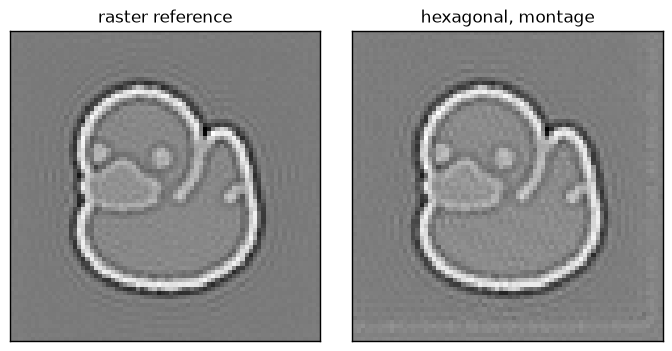

In [19]:
em.visualization.show_2d(
    [raster_reference, np.asarray(hex_montage.obj)],
    title=["raster reference", "hexagonal, montage"],
    axsize=(3.5, 3.5),
    norm="minmax",
);

## Kernels on the montage

Everything above used `prlx`, which is a translation.
The deconvolution kernels are convolutions on the canvas, evaluated exactly by FFT unless `convolution_mode="stencil"` is passed to truncate them to a box.

`icom` is a first-moment method rather than a deconvolution, so it has a different transfer function and is not expected to match the parallax reconstruction closely.
Truncating it to a stencil gives riCOM, where the radius acts as a high-pass cutoff.

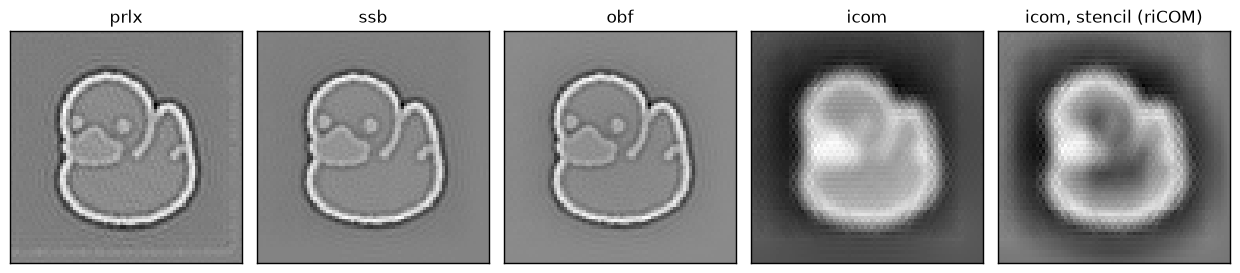

In [21]:
recons, titles = [], []
for kernel in ("prlx", "ssb", "obf", "icom"):
    hex_montage.reconstruct(
        deconvolution_kernel=kernel,
        upsampling_factor=upsampling,
        obj_origin=(0.0, 0.0),
        obj_fov=field_of_view,
        verbose=False,
    )
    recons.append(np.asarray(hex_montage.obj))
    titles.append(kernel)

hex_montage.reconstruct(
    deconvolution_kernel="icom",
    convolution_mode="stencil",
    stencil_radius=12,
    upsampling_factor=upsampling,
    obj_origin=(0.0, 0.0),
    obj_fov=field_of_view,
    verbose=False,
)
recons.append(np.asarray(hex_montage.obj))
titles.append("icom, stencil (riCOM)")

em.visualization.show_2d(recons, title=titles, axsize=(2.5, 2.8), norm="minmax");